<a href="https://colab.research.google.com/github/ashwin-aggarwal/systems-consolidation-demo/blob/main/systems_consolidation_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regulated Systems Consolidation
### A reimplementation of the core mechanism from Sun, Advani, Spruston, Saxe & Fitzgerald (2023), *Nature Neuroscience*

**Paper:** "Organizing memories for generalization in complementary learning systems"

This notebook rebuilds a simplified version of an idea from the paper: the brain
has two memory systems, a fast one that memorizes exact experiences, and a slow
one that learns general patterns from them. The question I'm testing: if the
slow system keeps absorbing memories from the fast one without limit, does it
eventually learn the noise instead of the real pattern? And does checking its
progress against a small "quiz" along the way prevent that?

I built this myself from the paper's description, rather than running the
authors' own code, so I'd actually understand the mechanism instead of just
reproducing a figure.

##1. Setup


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## 2. The Teacher
Generates (input, output) examples from a fixed random rule, with a
signal-to-noise ratio (SNR) controlling how much noise corrupts the output.
Low SNR = mostly noise. High SNR = the underlying rule dominates.

In [2]:
N = 20  # input dimension, higher dimensions means the 'student learner' actually has to begin to see the patterns

def make_teacher():
    w = torch.randn(N)
    return w / w.norm()  # unit-norm weight vector = the "true rule"

def teacher_generate(w_teacher, n_samples, snr):
    X = torch.randn(n_samples, N)
    y_true = X @ w_teacher
    noise_std = 0.0 if snr == float('inf') else (1.0 / snr) ** 0.5
    y_noisy = y_true + noise_std * torch.randn(n_samples) #corrupt the true answer with noise
    return X, y_true, y_noisy

w_teacher = make_teacher()
X_demo, y_true_demo, y_noisy_demo = teacher_generate(w_teacher, 5, snr=2.0)
print("true y:", y_true_demo)
print("noisy y:", y_noisy_demo)

true y: tensor([-0.2625,  1.6325,  0.2979,  0.6146,  1.2499])
noisy y: tensor([-0.1041,  2.0228, -0.1114,  0.6271,  1.3431])


## 3. The Notebook
Stores examples exactly, like a photographic memory, no learning or
generalizing happens here, it just remembers each example perfectly.
A small split of the notebook is set aside as a validation set (a mini quiz),
never trained on directly, only used to check whether more training is
still actually helping.

In [3]:
P = 60  # notebook capacity, memorizing 60 examples

def make_notebook(w_teacher, snr, val_frac=0.2):
    X, y_true, y_noisy = teacher_generate(w_teacher, P, snr)
    idx = torch.randperm(P)
    val_count = int(val_frac * P)
    val_idx = idx[:val_count] #testing batch for student
    train_idx = idx[val_count:] #trainging batch for student
    return X, y_noisy, train_idx, val_idx

X_nb, y_nb, train_idx, val_idx = make_notebook(w_teacher, snr=2.0)
print("notebook size:", X_nb.shape, "| train:", len(train_idx), "| val:", len(val_idx))

notebook size: torch.Size([60, 20]) | train: 48 | val: 12


## 4. The Student
This is the part that actually learns. It studies examples replayed from
the notebook and slowly adjusts its own guess at the underlying rule.
Two versions:
- **Unregulated**: keeps studying for the full time budget, no matter what.
- **Regulated**: checks itself against the quiz each round, and stops
  studying once it's no longer improving on the quiz.

In [4]:
def train_student(X_nb, y_nb, train_idx, val_idx, w_teacher,
                   max_epochs=120, lr=0.05, batch_size=30, regulate=False, patience=8):
    w = torch.zeros(N, requires_grad=False)
    X_test = torch.randn(400, N) #noiseless data ro measure generalization error
    y_test_true = X_test @ w_teacher

    gen_errors = []
    best_val = float('inf')
    best_w = w.clone()
    patience_count = 0
    frozen = False
    stop_epoch = None


    for epoch in range(1, max_epochs + 1):
        if not frozen:
            batch_idx = train_idx[torch.randint(0, len(train_idx), (batch_size,))]
            Xb, yb = X_nb[batch_idx], y_nb[batch_idx]
            preds = Xb @ w
            errors = preds - yb
            grad = (Xb * errors.unsqueeze(1)).mean(dim=0)
            #finding best w for gradient descent to lower error
            w = w - lr * grad

        #Checking how far student's guesses were
        gen_err = ((X_test @ w - y_test_true) ** 2).mean().item()
        gen_errors.append(gen_err)

        if regulate and not frozen:
            val_err = ((X_nb[val_idx] @ w - y_nb[val_idx]) ** 2).mean().item()
            if val_err < best_val - 1e-5:
                best_val = val_err
                best_w = w.clone()
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= patience:
                    frozen = True
                    w = best_w.clone()
                    stop_epoch = epoch

    return gen_errors, stop_epoch

gen_err_unreg, _ = train_student(X_nb, y_nb, train_idx, val_idx, w_teacher, regulate=False)
gen_err_reg, stop_epoch = train_student(X_nb, y_nb, train_idx, val_idx, w_teacher, regulate=True)

print("Regulated training stopped at epoch:", stop_epoch)

Regulated training stopped at epoch: 36


## 5. Single-Run Experiment
A function that runs one version of this setup (one teacher, one notebook)
through both training styles and plots how well the student is doing over
time.

In [5]:
def run_experiment(snr, val_frac=0.2, patience=8, max_epochs=120, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    w_teacher = make_teacher()
    X_nb, y_nb, train_idx, val_idx = make_notebook(w_teacher, snr, val_frac=val_frac)

    gen_err_unreg, _ = train_student(
        X_nb, y_nb, train_idx, val_idx, w_teacher,
        max_epochs=max_epochs, regulate=False
    )
    gen_err_reg, stop_epoch = train_student(
        X_nb, y_nb, train_idx, val_idx, w_teacher,
        max_epochs=max_epochs, regulate=True, patience=patience
    )

    plt.figure(figsize=(8, 5))
    plt.plot(gen_err_unreg, label="Unregulated", color="red")
    plt.plot(gen_err_reg, label="Regulated (early-stopped)", color="blue")
    if stop_epoch:
        plt.axvline(stop_epoch, linestyle="--", color="gray", alpha=0.6, label="Consolidation stops")
    plt.xlabel("Epoch")
    plt.ylabel("Generalization error (MSE)")
    plt.title(f"SNR = {snr} | val_frac = {val_frac} | patience = {patience}")
    plt.legend()
    plt.show()

    best_unreg = min(gen_err_unreg)
    final_reg = gen_err_reg[-1]
    print(f"Best unregulated error: {best_unreg:.3f}")
    print(f"Final regulated error:  {final_reg:.3f}")
    print(f"Stopped at epoch: {stop_epoch}")

    # return gen_err_unreg, gen_err_reg, stop_epoch

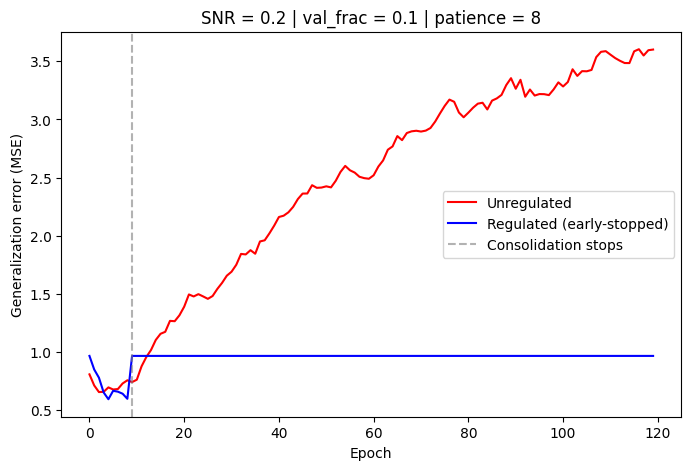

Best unregulated error: 0.657
Final regulated error:  0.968
Stopped at epoch: 9


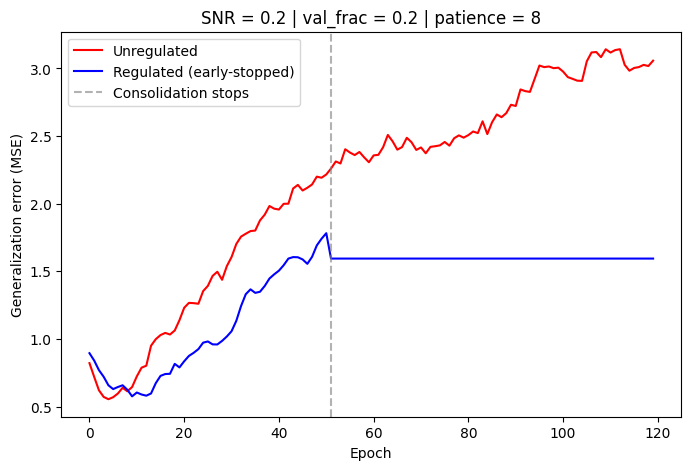

Best unregulated error: 0.554
Final regulated error:  1.594
Stopped at epoch: 51


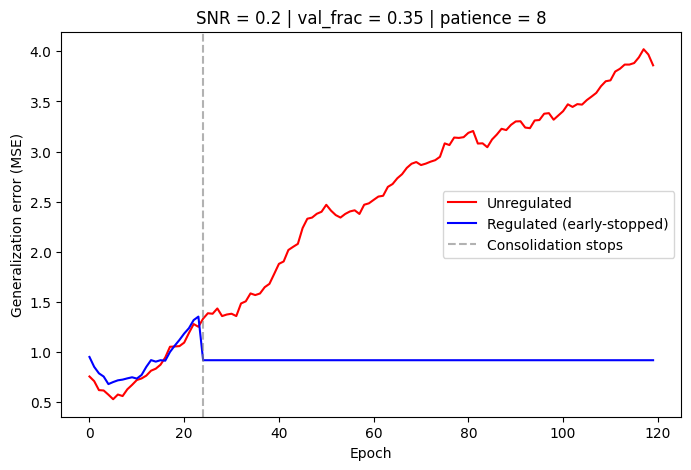

Best unregulated error: 0.531
Final regulated error:  0.919
Stopped at epoch: 24


In [13]:
run_experiment(snr=0.2, val_frac=0.1, patience=8, seed=0)   # 10%
run_experiment(snr=0.2, val_frac=0.2, patience=8, seed=0)  # 20%
run_experiment(snr=0.2, val_frac=0.35, patience=8, seed=0)   # 35%

##Observations
The middle one (20%) performed worse, perhaps due to sample size. Performing multiple trials  eliminates variance and gives us a more accurate representaion of what is really happening. Now I will try to run each one 10 times and average it.

## 7. Does Quiz Size Matter?
My first tests, trying a few different quiz sizes, gave confusing,
inconsistent results. Since each test only used one random teacher and
one random notebook, that inconsistency could just be bad luck rather than
a real pattern. To check, I reran each quiz size many times with different
random draws and averaged the results.

## 8. Averaging Many Runs for a Fair Comparison

In [11]:
def run_experiment_averaged(snr, val_frac=0.2, patience=8, max_epochs=120, n_seeds=10):
    all_unreg = []
    all_reg = []
    stop_epochs = []

    for seed in range(n_seeds):
        torch.manual_seed(seed)
        w_teacher = make_teacher()
        X_nb, y_nb, train_idx, val_idx = make_notebook(w_teacher, snr, val_frac=val_frac)

        gen_err_unreg, _ = train_student(
            X_nb, y_nb, train_idx, val_idx, w_teacher,
            max_epochs=max_epochs, regulate=False
        )
        gen_err_reg, stop_epoch = train_student(
            X_nb, y_nb, train_idx, val_idx, w_teacher,
            max_epochs=max_epochs, regulate=True, patience=patience
        )

        all_unreg.append(gen_err_unreg)
        all_reg.append(gen_err_reg)
        stop_epochs.append(stop_epoch if stop_epoch else max_epochs)

    all_unreg = np.array(all_unreg)  # shape: (n_seeds, max_epochs)
    all_reg = np.array(all_reg)

    mean_unreg, std_unreg = all_unreg.mean(axis=0), all_unreg.std(axis=0)
    mean_reg, std_reg = all_reg.mean(axis=0), all_reg.std(axis=0)

    epochs = np.arange(1, max_epochs + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, mean_unreg, label="Unregulated (mean)", color="red")
    plt.fill_between(epochs, mean_unreg - std_unreg, mean_unreg + std_unreg, color="blue", alpha=0.15)
    plt.plot(epochs, mean_reg, label="Regulated (mean)", color="gray")
    plt.fill_between(epochs, mean_reg - std_reg, mean_reg + std_reg, color="#2CA89B", alpha=0.15)
    plt.xlabel("Epoch")
    plt.ylabel("Generalization error (MSE)")
    plt.title(f"Averaged over {n_seeds} seeds | SNR={snr} | val_frac={val_frac} | patience={patience}")
    plt.legend()
    plt.show()

    final_reg_mean = mean_reg[-1]
    best_unreg_mean = mean_unreg.min()
    print(f"Mean best unregulated error: {best_unreg_mean:.3f}")
    print(f"Mean final regulated error:  {final_reg_mean:.3f}")
    print(f"Mean stop epoch: {np.mean(stop_epochs):.1f}  (std: {np.std(stop_epochs):.1f})")

    # return mean_unreg, mean_reg, stop_epochs

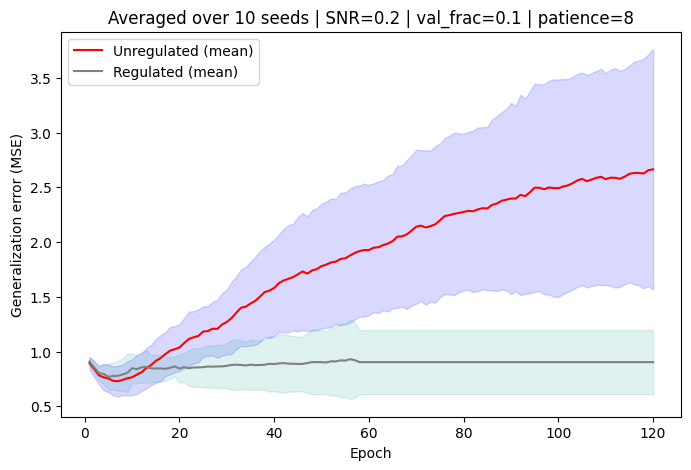

Mean best unregulated error: 0.728
Mean final regulated error:  0.903
Mean stop epoch: 16.6  (std: 14.1)


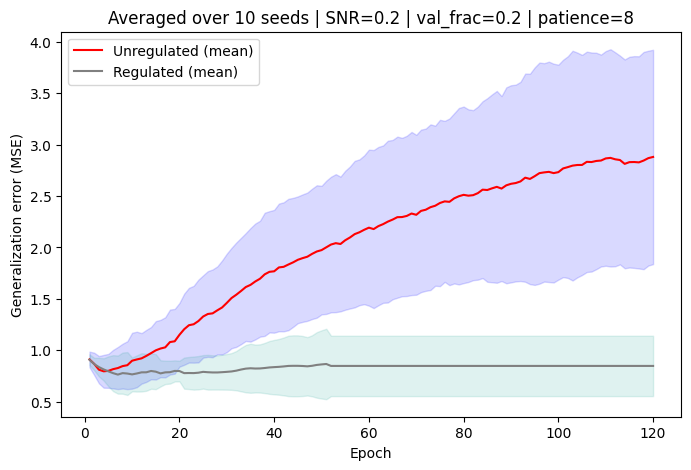

Mean best unregulated error: 0.795
Mean final regulated error:  0.848
Mean stop epoch: 17.6  (std: 12.2)


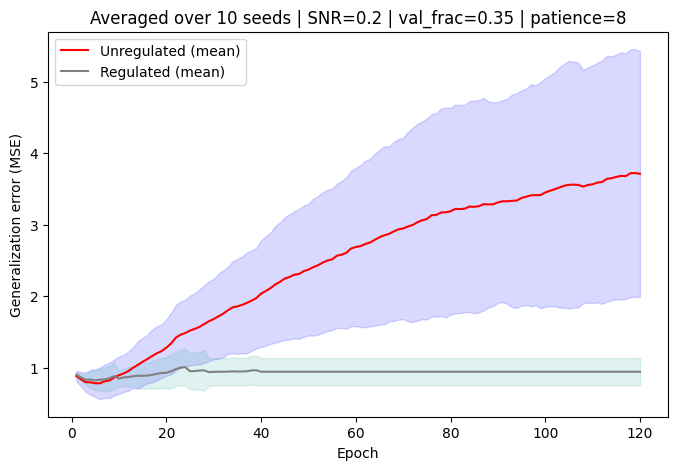

Mean best unregulated error: 0.783
Mean final regulated error:  0.944
Mean stop epoch: 18.2  (std: 10.0)


In [12]:
run_experiment_averaged(snr=0.2, val_frac=0.1, patience=8, n_seeds=10)
run_experiment_averaged(snr=0.2, val_frac=0.2, patience=8, n_seeds=10)
run_experiment_averaged(snr=0.2, val_frac=0.35, patience=8, n_seeds=10)

##Observations

- Bigger validation sets makes the 'stopping point' more consistent. We can see this by the standard deviation decreasing as quiz set size increased.
- However, the best score (Regulated error) came from the middle set, meaning there is a happy medium between bigger quiz sets and pattern recognition.
If the quiz set is too big that means the student was not exposed to enough training data and was not able to pick up the underlying patterns and really understand what was happening and it ended up overfitting on what it did see. And if the validation set was to small then the set can give a a noisy signal and the resulting measurement is not statsitically reliable, as we can see from the standard deviation.


-  The unregulated error increases steadily as training continues, since nothing tells it to stop. Early on (around epoch 10) it actually dips below the regulated line, briefly learning the real pattern faster. But past that point, since it never checks the validation set, it keeps fitting to noise in the training data rather than the underlying rule (leading to memorization and overfitting), which is what drives generalization error back up.

- This is a common trade off in machine learning on what size to make the validation and training split.

## 10. What I'd Try Next

- Change how much the notebook can store in total, to check whether it's
  really "less material to study" causing the quiz-size trade-off, not
  something else.
- Make the notebook's memory more brain-like (a Hopfield network instead of
  just a plain list), since that's what the real paper uses, and see if
  that changes anything. (I am still learning more about this and math behind it)
- Try a teacher whose rule isn't just a straight line (something the student
  can't perfectly represent), to see if "stopping point"
  matters even more in that harder case. Because even a perfectly trained student would have some irreducible error, so it would have to approximate a straight line to fit a curve, which I think is a more real-world approach to this problem.
  